In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    dataset_name='kang_15K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)
scarf.fetch_dataset(
    dataset_name='kang_14K_ifnb-pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

ds_ctrl = scarf.DataStore('scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr')
ds_stim = scarf.DataStore('scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr')

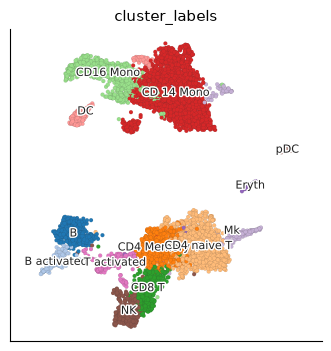

In [2]:
splt.embedding(
    ds_ctrl,
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
    show=False,
).figure;

In [3]:
splt.embedding(
    ds_stim,
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
    show=False,
).figure;

In [4]:
ds_ctrl.cells.insert(
    'reference_batch',
    np.repeat('control', ds_ctrl.cells.N),
    overwrite=True
)

reference = ds_ctrl.build_mapping_reference(
    feat_key='hvgs',
    batch_columns=['reference_batch']
)

In [5]:
reference = ds_ctrl.get_mapping_reference(feat_key='hvgs')

In [6]:
result = reference.map_query(
    target_assay=ds_stim.RNA,
    target_name='stim_symphony',
    target_feat_key='hvgs_symphony',
    save_k=5,
    query_batches=pd.DataFrame(
        {
            'reference_batch': np.repeat(
                'stimulated',
                len(ds_stim.cells.fetch('ids', key='I'))
            )
        }
    )
)
result

MappingResult(projection_path='RNA/projections/stim_symphony', n_cells=10111, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1.0, 'zeroNormCellCount': 0.0, 'algorithmVariant': 'symphonyStyleV1'}, indices=None, distances=None, uncorrected_latent=None, corrected_latent=None, uninformative=None)

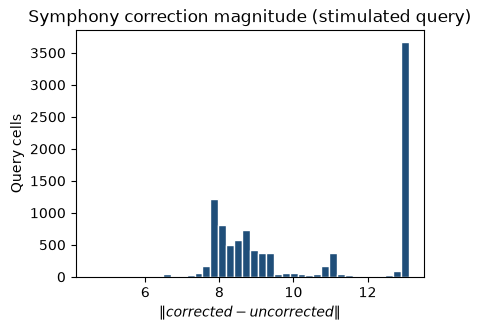

In [7]:
projection = ds_ctrl.z['RNA']['projections']['stim_symphony']
dict(projection.attrs)

uncorrected = projection['uncorrectedLatent'][:]
corrected = projection['correctedLatent'][:]
shift = np.linalg.norm(corrected - uncorrected, axis=1)

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(shift, bins=40, color='#1f4e79', edgecolor='white')
ax.set_xlabel(r'$\|corrected - uncorrected\|$')
ax.set_ylabel('Query cells')
ax.set_title('Symphony correction magnitude (stimulated query)')
fig

In [8]:
transferred = ds_ctrl.get_target_classes(
    target_name='stim_symphony',
    reference_class_group='cluster_labels',
)
ds_stim.cells.insert('symphony_labels', transferred.values, overwrite=True)

splt.embedding(
    ds_stim,
    layout_key='RNA_UMAP',
    color_by='symphony_labels',
    show=False,
).figure;

In [9]:
pd.crosstab(
    ds_stim.cells.fetch('cluster_labels'),
    ds_stim.cells.fetch('symphony_labels'),
)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,652,22,1,11,27,6,1,0,0,6,11,1,5,3
B activated,14,185,0,1,1,1,0,0,0,0,3,0,0,0
CD 14 Mono,0,0,279,2252,0,0,0,1,0,0,0,0,0,0
CD16 Mono,0,0,0,955,0,0,0,0,0,1,0,0,0,0
CD4 Memory T,0,0,1,3,1088,71,115,0,0,2,15,0,2,0
CD4 naive T,8,4,2,3,674,1644,12,0,0,4,22,2,15,0
CD8 T,0,0,0,0,13,1,546,0,0,2,6,86,1,0
DC,0,0,7,129,0,0,0,77,0,0,1,0,0,0
Eryth,0,0,1,10,5,19,1,0,45,0,2,0,0,0


In [10]:
evidence = ds_ctrl.get_target_label_evidence(
    target_name='stim_symphony',
    reference_class_group='cluster_labels',
    threshold_fraction=0.6
)
evidence.head()

,label,voteFraction,voteEntropy,topTwoMargin,featureCoverage,referenceDistancePercentile,isUnknown
0,CD8 T,0.619149,0.664479,0.238298,1.0,0.718168,False
1,pDC,1.000000,-0.000000,1.000000,1.0,0.856477,False
2,CD4 naive T,1.000000,-0.000000,1.000000,1.0,0.695549,False
3,B,1.000000,-0.000000,1.000000,1.0,0.863320,False
4,CD4 naive T,0.792535,0.510579,0.585070,1.0,0.503071,False


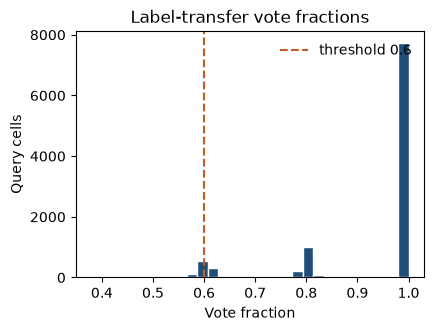

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(evidence['voteFraction'].dropna(), bins=30, color='#1f4e79', edgecolor='white')
ax.axvline(0.6, color='#c45c26', linestyle='--', label='threshold 0.6')
ax.set_xlabel('Vote fraction')
ax.set_ylabel('Query cells')
ax.set_title('Label-transfer vote fractions')
ax.legend(frameon=False)
fig

In [12]:
calibrated = ds_ctrl.get_target_label_evidence(
    target_name='stim_symphony',
    reference_class_group='cluster_labels',
    calibration_nonconformity=np.array([0.08, 0.12, 0.2, 0.25]),
    conformal_alpha=0.1
)
calibrated[['label', 'predictionSet']].head()

,label,predictionSet
0,CD8 T,"(CD4 naive T, CD 14 Mono, pDC, CD4 Memory T, T..."
1,pDC,"(CD4 naive T, CD 14 Mono, pDC, CD4 Memory T, T..."
2,CD4 naive T,"(CD4 naive T, CD 14 Mono, pDC, CD4 Memory T, T..."
3,B,"(CD4 naive T, CD 14 Mono, pDC, CD4 Memory T, T..."
4,CD4 naive T,"(CD4 naive T, CD 14 Mono, pDC, CD4 Memory T, T..."


In [13]:
control_result = reference.map_query(
    target_assay=ds_ctrl.RNA,
    target_name='control_symphony',
    target_feat_key='hvgs_control_symphony',
    save_k=5,
    query_batches=pd.DataFrame(
        {'reference_batch': ds_ctrl.cells.fetch('reference_batch', key='I')}
    )
)
control_result

MappingResult(projection_path='RNA/projections/control_symphony', n_cells=8487, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1.0, 'zeroNormCellCount': 0.0, 'algorithmVariant': 'symphonyStyleV1'}, indices=None, distances=None, uncorrected_latent=None, corrected_latent=None, uninformative=None)

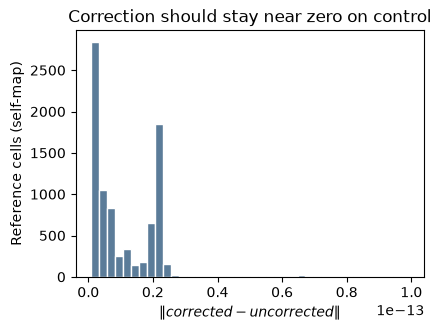

In [14]:
ctrl_proj = ds_ctrl.z['RNA']['projections']['control_symphony']
ctrl_unc = ctrl_proj['uncorrectedLatent'][:]
ctrl_cor = ctrl_proj['correctedLatent'][:]
ctrl_shift = np.linalg.norm(ctrl_cor - ctrl_unc, axis=1)

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(ctrl_shift, bins=40, color='#5b7c99', edgecolor='white')
ax.set_xlabel(r'$\|corrected - uncorrected\|$')
ax.set_ylabel('Reference cells (self-map)')
ax.set_title('Correction should stay near zero on control')
fig